In [1]:
# Colab setup — skip if running locally
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q mne einops torch torchvision scikit-learn
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd drive/MyDrive/Neurotech\ 25-26/ml_model

/content/drive/MyDrive/Neurotech 25-26/ml_model


In [3]:
%ls

dataloader.py     loso_models/            __pycache__/
DeepConvNet.pt    models.py               results.txt
gridsearch.ipynb  preprocess_pipeline.py  train_loso.ipynb


In [4]:
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report

# Path setup — works both locally and on Colab (after mounting Drive)
if 'google.colab' in sys.modules:
    REPO_ROOT = '/content/drive/MyDrive/weimo'
else:
    REPO_ROOT = os.path.join(os.path.dirname(os.path.abspath('.')), '')

sys.path.insert(0, REPO_ROOT)
from preprocess_pipeline import MNEPipeline, notch, bandpass, rereference, add_idle_class, epoch, epoch_filter, extract_tensor
from models import DeepConvNet, ShallowConvNet, EEGNet, ATCNet, Conformer, CTNet, MBMANet, LMDANet, EEGITNet

In [5]:
# =============================================================================
# Configuration
# =============================================================================

N_CHANNELS   = 8
N_CLASSES    = 3
SFREQ        = 300
TRIAL_DUR    = 3.0
N_TIMEPOINTS = int(SFREQ * TRIAL_DUR) + 1  # 901 — MNE tmax is inclusive

LABEL_MAP = {'idle': 0, 'move': 1, 'jaw_clench': 2}
MAP_LABEL = {v: k for k, v in LABEL_MAP.items()}
BANDPASS  = [(13, 30)]   # best config from gridsearch

EPOCHS     = 500
BATCH_SIZE = 32
LR         = 1e-4        # best lr from gridsearch
PATIENCE   = 20
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── File paths ────────────────────────────────────────────────────────────────
# Local paths (relative to ml_model/). Update the Colab block if running on Drive.
if 'google.colab' in sys.modules:
    DATA_DIR = '/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg'
else:
    DATA_DIR = os.path.join(REPO_ROOT, 'data_collection', 'annotated_eeg')

FILES = [
    os.path.join(DATA_DIR, 'chengyi_4_8_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_8_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_0.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_1.fif'),
    os.path.join(DATA_DIR, 'chengyi_4_9_2.fif'),
]

SAVE_DIR = './loso_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Preprocessing modes to compare ──────────────────────────────────────────
# Each entry runs as a separate LOSO sweep. Remove one to skip it.
PREPROCESS_MODES = {
    'whole_file': False,  # filter continuous recording → epoch
    'per_epoch' : True,   # epoch first → filter each trial independently
}

print(f'Device      : {DEVICE}')
print(f'N_TIMEPOINTS: {N_TIMEPOINTS}')
print(f'Files       : {len(FILES)}')

Device      : cuda
N_TIMEPOINTS: 901
Files       : 5


In [6]:
# =============================================================================
# Model registry
# =============================================================================

MODEL_REGISTRY = {
    'DeepConvNet'  : lambda: DeepConvNet(N_CHANNELS, N_CLASSES),
    # 'ShallowConvNet': lambda: ShallowConvNet(N_CHANNELS, N_CLASSES),
    # 'EEGNet'       : lambda: EEGNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'ATCNet'       : lambda: ATCNet(N_CHANNELS, N_CLASSES, SFREQ),
    # 'Conformer'    : lambda: Conformer(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    # 'CTNet'        : lambda: CTNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'MBMANet'      : lambda: MBMANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    # 'LMDANet'      : lambda: LMDANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    # 'EEGITNet'     : lambda: EEGITNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
}

In [7]:
# =============================================================================
# Data loading
# =============================================================================

def load_session(fif_path, per_epoch=False):
    """Preprocess one .fif file and return (X, y) with integer labels.

    X shape: (n_trials, 1, N_CHANNELS, N_TIMEPOINTS)  float32
    y shape: (n_trials,)  int64

    per_epoch=False: filter/rereference on the continuous recording, then epoch.
    per_epoch=True : epoch with minimal processing first, then filter each trial.
    """
    extractor = extract_tensor(scale=True, per_epoch_scale=True)

    pipeline = MNEPipeline(fif_path)
    if not per_epoch:
        pipeline.add(notch(60))
        pipeline.add(bandpass(BANDPASS))
        pipeline.add(rereference())
    pipeline.add(add_idle_class(window_dur=TRIAL_DUR, idle_start_min=1.0))
    pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))
    if per_epoch:
        pipeline.add(epoch_filter(bands=BANDPASS, notch_freq=60, ref='average'))
    raw = pipeline.run()

    X, y_raw = extractor(raw)

    # remap MNE's auto-assigned event IDs to consistent 0/1/2
    auto_ids = raw._event_id
    remap = {v: LABEL_MAP[k] for k, v in auto_ids.items() if k in LABEL_MAP}
    y = np.array([remap[yi] for yi in y_raw], dtype=np.int64)

    # trim/pad to exact N_TIMEPOINTS in case of rounding differences
    T = X.shape[-1]
    if T > N_TIMEPOINTS:
        X = X[..., :N_TIMEPOINTS]
    elif T < N_TIMEPOINTS:
        pad = np.zeros((*X.shape[:-1], N_TIMEPOINTS - T), dtype=np.float32)
        X = np.concatenate([X, pad], axis=-1)

    print(f'  {os.path.basename(fif_path)}: X={X.shape}  classes={dict(zip(*np.unique(y, return_counts=True)))}')
    return X, y


def balance_classes(X, y):
    """Undersample majority classes to match the smallest class."""
    unique, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    idx = np.concatenate([
        np.random.choice(np.where(y == c)[0], size=min_count, replace=False)
        for c in unique
    ])
    np.random.shuffle(idx)
    return X[idx], y[idx]


In [8]:
# =============================================================================
# Preload all sessions (one set per preprocessing mode)
# =============================================================================

print('Loading sessions...')
all_sessions = {
    mode: [load_session(f, per_epoch=flag) for f in FILES]
    for mode, flag in PREPROCESS_MODES.items()
}
print(f'\nDone. {len(FILES)} sessions × {len(PREPROCESS_MODES)} preprocessing modes loaded.')


Loading sessions...
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_0.fif...
Isotrak not found
    Range : 0 ... 287999 =      0.000 ...   959.997 secs
Ready.


/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_0.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


Reading 0 ... 287999  =      0.000 ...   959.997 secs...
Applying: <function notch.<locals>.apply at 0x7df9c10545e0>
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Applying: <function bandpass.<locals>.apply at 0x7df9c1054ae0>
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_8_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


Applying: <function bandpass.<locals>.apply at 0x7df9c10545e0>
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 305 samples (1.017 s)

Applying: <function rereference.<locals>.apply at 0x7df9c1054ae0>
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying: <function add_idle_class.<locals>.apply at 0x7df9c1054360>
[idle] Added 123 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x7df84bd5fa60>
Used Annotations des

...

[Tensor] shape: (186, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_0.fif: X=(186, 1, 8, 901)  classes={np.int64(0): np.int64(112), np.int64(1): np.int64(38), np.int64(2): np.int64(36)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_1.fif...
Isotrak not found
    Range : 0 ... 272999 =      0.000 ...   909.997 secs
Ready.
Reading 0 ... 272999  =      0.000 ...   909.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x7df9c10545e0>
[idle] Added 119 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x7df9c10c6f20>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
193 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 193 events and 901 original time points ...
0 bad epochs dropped
Epoched: 193 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <func

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (193, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_1.fif: X=(193, 1, 8, 901)  classes={np.int64(0): np.int64(119), np.int64(1): np.int64(38), np.int64(2): np.int64(36)}
Opening raw data file /content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_2.fif...
Isotrak not found
    Range : 0 ... 266999 =      0.000 ...   889.997 secs
Ready.
Reading 0 ... 266999  =      0.000 ...   889.997 secs...
Applying: <function add_idle_class.<locals>.apply at 0x7df84996be20>
[idle] Added 115 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x7df84996bec0>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
189 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 189 events and 901 original time points ...
0 bad epochs dropped
Epoched: 189 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Applying: <func

/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:340: RuntimeWarning: This filename (/content/drive/MyDrive/Neurotech 25-26/data/annotated_eeg/chengyi_4_9_2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)
/content/drive/MyDrive/Neurotech 25-26/ml_model/preprocess_pipeline.py:196: RuntimeWarning: filter_length (1981) is longer than the signal (901), distortion is likely. Reduce filter length or filter a longer signal.
  data = mne.filter.notch_filter(data, Fs=raw._epochs.info['sfreq'], freqs=notch_freq, verbose=False)


[Tensor] shape: (189, 1, 8, 901)  scale=per-epoch
  chengyi_4_9_2.fif: X=(189, 1, 8, 901)  classes={np.int64(0): np.int64(115), np.int64(1): np.int64(38), np.int64(2): np.int64(36)}

Done. 5 sessions × 2 preprocessing modes loaded.


In [9]:
# =============================================================================
# Training utilities
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * len(yb)
        correct    += (out.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def compute_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
    acc   = accuracy_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(all_labels, all_preds)
    cm    = confusion_matrix(all_labels, all_preds)
    return {'accuracy': acc, 'f1_macro': f1, 'kappa': kappa, 'confusion_matrix': cm,
            'preds': all_preds, 'labels': all_labels}

In [10]:
# =============================================================================
# LOSO training loop
# =============================================================================

all_results = []

# best model per (architecture, preprocessing mode)
best_per_model = {
    name: {mode: {'accuracy': -1} for mode in PREPROCESS_MODES}
    for name in MODEL_REGISTRY
}

for preproc_name, per_epoch_flag in PREPROCESS_MODES.items():
    sessions = all_sessions[preproc_name]
    print(f'\n{"#"*60}')
    print(f'PREPROCESSING MODE: {preproc_name}')
    print(f'{"#"*60}')

    for fold_idx in range(len(FILES)):
        val_session = os.path.basename(FILES[fold_idx])
        print(f'\n{"="*60}')
        print(f'FOLD {fold_idx+1}/{len(FILES)}  |  Val session: {val_session}')
        print(f'{"="*60}')

        val_X, val_y = sessions[fold_idx]

        train_X = np.concatenate([sessions[j][0] for j in range(len(FILES)) if j != fold_idx])
        train_y = np.concatenate([sessions[j][1] for j in range(len(FILES)) if j != fold_idx])
        train_X, train_y = balance_classes(train_X, train_y)

        print(f'  Train: {train_X.shape}  Val: {val_X.shape}')
        unique, counts = np.unique(train_y, return_counts=True)
        print(f'  Train class dist: { {MAP_LABEL[c]: int(n) for c, n in zip(unique, counts)} }')
        unique, counts = np.unique(val_y, return_counts=True)
        print(f'  Val class dist  : { {MAP_LABEL[c]: int(n) for c, n in zip(unique, counts)} }')

        train_ds = TensorDataset(torch.tensor(train_X), torch.tensor(train_y))
        val_ds   = TensorDataset(torch.tensor(val_X),   torch.tensor(val_y))
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

        criterion = nn.CrossEntropyLoss()

        for model_name, model_fn in MODEL_REGISTRY.items():
            print(f'\n  [{model_name}]')
            try:
                model     = model_fn().to(DEVICE)
                optimizer = torch.optim.Adam(model.parameters(), lr=LR)
                scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

                best_val_loss  = float('inf')
                best_state     = None
                patience_count = 0

                for ep in range(1, EPOCHS + 1):
                    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
                    va_loss, va_acc = eval_epoch(model, val_loader, criterion, DEVICE)
                    scheduler.step()

                    if ep % 50 == 0:
                        print(f'    ep {ep:3d} | tr {tr_loss:.4f}/{tr_acc:.3f} | va {va_loss:.4f}/{va_acc:.3f}')

                    if va_loss < best_val_loss - 1e-4:
                        best_val_loss  = va_loss
                        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                        patience_count = 0
                    else:
                        patience_count += 1
                        if patience_count >= PATIENCE:
                            print(f'    Early stop at epoch {ep}')
                            break

                model.load_state_dict(best_state)
                metrics = compute_metrics(model, val_loader, DEVICE)

                print(f'    acc={metrics["accuracy"]:.4f}  f1={metrics["f1_macro"]:.4f}  kappa={metrics["kappa"]:.4f}')

                result = {
                    'fold'        : fold_idx,
                    'val_session' : val_session,
                    'preproc'     : preproc_name,
                    'model_name'  : model_name,
                    'accuracy'    : metrics['accuracy'],
                    'f1_macro'    : metrics['f1_macro'],
                    'kappa'       : metrics['kappa'],
                    'confusion_matrix': metrics['confusion_matrix'].tolist(),
                    'model'       : model,
                }
                all_results.append(result)

                if metrics['accuracy'] > best_per_model[model_name][preproc_name]['accuracy']:
                    best_per_model[model_name][preproc_name] = result
                    save_path = os.path.join(SAVE_DIR, f'{model_name}_{preproc_name}.pt')
                    torch.save(best_state, save_path)
                    config = {
                        'model_name'  : model_name,
                        'preproc'     : preproc_name,
                        'val_session' : val_session,
                        'accuracy'    : metrics['accuracy'],
                        'f1_macro'    : metrics['f1_macro'],
                        'kappa'       : metrics['kappa'],
                        'N_CHANNELS'  : N_CHANNELS,
                        'N_CLASSES'   : N_CLASSES,
                        'N_TIMEPOINTS': N_TIMEPOINTS,
                        'SFREQ'       : SFREQ,
                        'TRIAL_DUR'   : TRIAL_DUR,
                        'BANDPASS'    : BANDPASS,
                    }
                    with open(save_path.replace('.pt', '_config.json'), 'w') as f:
                        json.dump(config, f, indent=2)
                    print(f'    Saved best {model_name}/{preproc_name} (acc={metrics["accuracy"]:.4f})')

            except Exception as e:
                print(f'    ERROR: {e}')
                all_results.append({
                    'fold': fold_idx, 'val_session': val_session,
                    'preproc': preproc_name, 'model_name': model_name,
                    'accuracy': None, 'f1_macro': None, 'kappa': None,
                    'confusion_matrix': None, 'model': None,
                })

print('\nLOSO training complete.')



############################################################
PREPROCESSING MODE: whole_file
############################################################

FOLD 1/5  |  Val session: chengyi_4_8_0.fif
  Train: (432, 1, 8, 901)  Val: (205, 1, 8, 901)
  Train class dist: {'idle': 144, 'move': 144, 'jaw_clench': 144}
  Val class dist  : {'idle': 131, 'move': 38, 'jaw_clench': 36}

  [DeepConvNet]
    Early stop at epoch 42
    acc=0.8683  f1=0.8427  kappa=0.7488
    Saved best DeepConvNet/whole_file (acc=0.8683)

FOLD 2/5  |  Val session: chengyi_4_8_1.fif
  Train: (432, 1, 8, 901)  Val: (197, 1, 8, 901)
  Train class dist: {'idle': 144, 'move': 144, 'jaw_clench': 144}
  Val class dist  : {'idle': 123, 'move': 38, 'jaw_clench': 36}

  [DeepConvNet]
    ep  50 | tr 0.5571/0.998 | va 0.7911/0.756
    Early stop at epoch 50
    acc=0.8426  f1=0.8084  kappa=0.7021

FOLD 3/5  |  Val session: chengyi_4_9_0.fif
  Train: (432, 1, 8, 901)  Val: (186, 1, 8, 901)
  Train class dist: {'idle': 144, 'mov

In [11]:
# =============================================================================
# Results table
# =============================================================================

df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('model', 'confusion_matrix')}
    for r in all_results
])
df = df.dropna(subset=['accuracy'])

summary = (
    df.groupby(['preproc', 'model_name'])[['accuracy', 'f1_macro', 'kappa']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('accuracy', 'mean'), ascending=False)
)
print('LOSO summary (mean ± std across folds):')
print(summary.to_string())


LOSO summary (mean ± std across folds):
                       accuracy         f1_macro           kappa        
                           mean     std     mean     std    mean     std
preproc    model_name                                                   
whole_file DeepConvNet   0.8811  0.0300   0.8616  0.0391  0.7791  0.0594
per_epoch  DeepConvNet   0.7777  0.0934   0.7271  0.1512  0.5715  0.2136


In [12]:
# =============================================================================
# Per-fold breakdown
# =============================================================================

pivot = df.pivot_table(
    index=['preproc', 'model_name'], columns='val_session', values='accuracy'
).round(4)
pivot['mean'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean', ascending=False)
print('Accuracy per held-out session:')
print(pivot.to_string())


Accuracy per held-out session:
val_session             chengyi_4_8_0.fif  chengyi_4_8_1.fif  chengyi_4_9_0.fif  chengyi_4_9_1.fif  chengyi_4_9_2.fif     mean
preproc    model_name                                                                                                         
whole_file DeepConvNet             0.8683             0.8426             0.9247             0.8808             0.8889  0.88106
per_epoch  DeepConvNet             0.7805             0.6294             0.8387             0.7668             0.8730  0.77768


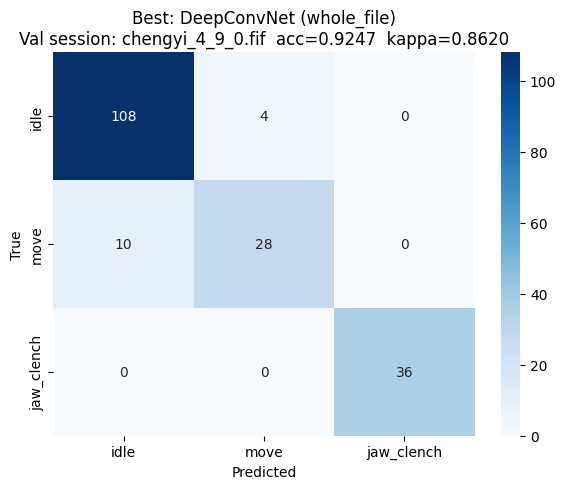

Best: DeepConvNet (whole_file)  val=chengyi_4_9_0.fif  acc=0.9247


In [13]:
# =============================================================================
# Confusion matrix — best model + preprocessing mode, best fold
# =============================================================================

best_result = max(
    [r for r in all_results if r['accuracy'] is not None],
    key=lambda r: r['accuracy']
)

cm = np.array(best_result['confusion_matrix'])
class_names = [MAP_LABEL[i] for i in range(N_CLASSES)]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'Best: {best_result["model_name"]} ({best_result["preproc"]})\n'
    f'Val session: {best_result["val_session"]}  '
    f'acc={best_result["accuracy"]:.4f}  kappa={best_result["kappa"]:.4f}'
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'best_confusion_matrix.png'), dpi=120)
plt.show()
print(f'Best: {best_result["model_name"]} ({best_result["preproc"]})  val={best_result["val_session"]}  acc={best_result["accuracy"]:.4f}')
